# University Ranking 2022
### Data Cleaning → EDA → Normalization → Entropy Weights → AHP Weights → TOPSIS Ranking
**Project:** A Data-Driven Framework for Global University Ranking using MCDM
**Author:** Kuldeep Kumar Mishra | MSD24006 | IIIT Lucknow

---
## Install and Import Libraries

In [1]:
# Install libraries
!pip install plotly -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

print('All libraries imported successfully!')

All libraries imported successfully!


---
## Load Data

In [2]:



from google.colab import files
uploaded = files.upload()

import io
filename = list(uploaded.keys())[0]
df_raw = pd.read_csv(io.BytesIO(uploaded[filename]))



Saving 2022.csv to 2022.csv


---
## Data Cleaning

In [3]:

df = df_raw.copy()

# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print('Columns after cleaning:', list(df.columns))

Columns after cleaning: ['rank', 'name', 'country', 'student_population', 'students_to_staff_ratio', 'international_students', 'female_to_male_ratio', 'overall_score', 'teaching', 'research_environment', 'research_quality', 'industry_impact', 'international_outlook', 'year']


In [4]:
# Rename columns for convenience
df.rename(columns={
    'name'                  : 'university',
    'student_population'    : 'student_pop',
    'students_to_staff_ratio': 'student_staff_ratio',
    'international_students': 'intl_students_pct',
    'female_to_male_ratio'  : 'female_male_ratio',
    'overall_score'         : 'overall_score',
    'research_environment'  : 'research_env',
    'research_quality'      : 'research_qual',
    'industry_impact'       : 'industry',
    'international_outlook' : 'intl_outlook'
}, inplace=True)

df.head(3)

,rank,university,country,student_pop,student_staff_ratio,intl_students_pct,female_male_ratio,overall_score,teaching,research_env,research_qual,industry,intl_outlook,year
0,1.0000,University of Oxford,United Kingdom,20835.0000,10.7000,42%,47:53:00,95.6625,91.0000,99.6000,98.0000,74.4000,96.3000,2022
1,2.0000,California Institute of Technology,United States,2233.0000,6.3000,34%,36 : 64,95.0350,93.6000,96.9000,97.8000,90.4000,83.8000,2022
2,3.0000,Harvard University,United States,21574.0000,9.5000,24%,50:50:00,94.9875,94.5000,98.9000,99.2000,48.9000,79.8000,2022


In [5]:
# Clean 'international_students' remove % sign
df['intl_students_pct'] = (
    df['intl_students_pct']
    .astype(str)
    .str.replace('%', '', regex=False)
    .str.strip()
)
df['intl_students_pct'] = pd.to_numeric(df['intl_students_pct'], errors='coerce')

print('intl_students_pct sample:')
print(df['intl_students_pct'].head(10).tolist())

intl_students_pct sample:
[42.0, 34.0, 24.0, 23.0, 33.0, 39.0, 23.0, 23.0, 21.0, 33.0]


In [6]:
# Clean 'female_male_ratio'  extract female % only
def parse_female_ratio(val):
    val = str(val).strip()

    try:
        f = float(val)
        if f < 2:   # it's a decimal ratio, not a percentage
            return round(f / (1 + f) * 100, 2)
    except:
        pass
    # Handle 'XX:YY' or 'XX : YY' format
    if ':' in val:
        parts = val.split(':')
        try:
            female = float(parts[0].strip())
            male   = float(parts[1].strip())
            if female + male > 0:
                return round(female / (female + male) * 100, 2)
        except:
            pass
    return np.nan

df['female_pct'] = df['female_male_ratio'].apply(parse_female_ratio)
print('female_pct sample:')
print(df['female_pct'].head(10).tolist())

female_pct sample:
[47.0, 36.0, 50.0, 46.0, 40.0, 47.0, 47.0, 51.0, 51.0, 46.0]


In [7]:
# Ensure numeric types for key columns
numeric_cols = [
    'rank', 'student_pop', 'student_staff_ratio',
    'overall_score', 'teaching', 'research_env',
    'research_qual', 'industry', 'intl_outlook'
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('Dtypes:')
print(df[numeric_cols].dtypes)

Dtypes:
rank                   float64
student_pop            float64
student_staff_ratio    float64
overall_score          float64
teaching               float64
research_env           float64
research_qual          float64
industry               float64
intl_outlook           float64
dtype: object


In [8]:
# Check missing values
print('=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
print(missing_df[missing_df['missing_count'] > 0])

=== Missing Values ===
                   missing_count  missing_%
intl_students_pct              1     0.0600
female_male_ratio             71     4.2700
female_pct                    71     4.2700


In [9]:
# Fill missing values in MCDM criteria with median
criteria_cols = ['teaching', 'research_env', 'research_qual', 'industry', 'intl_outlook']

for col in criteria_cols:
    median_val = df[col].median()
    missing_count = df[col].isnull().sum()
    df[col].fillna(median_val, inplace=True)
    print(f'{col}: filled {missing_count} missing values with median={median_val:.2f}')

teaching: filled 0 missing values with median=23.30
research_env: filled 0 missing values with median=17.10
research_qual: filled 0 missing values with median=46.20
industry: filled 0 missing values with median=39.50
intl_outlook: filled 0 missing values with median=42.30


In [10]:
# Remove duplicate rows
before = len(df)
df.drop_duplicates(subset=['university'], keep='first', inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Duplicates removed: {before - len(df)} | Remaining rows: {len(df)}')

Duplicates removed: 0 | Remaining rows: 1662


In [11]:
# Final cleaned dataset
print('=== Cleaned Dataset Info ===')
print(f'Shape: {df.shape}')
df[criteria_cols + ['university', 'country', 'rank', 'overall_score']].head(10)

=== Cleaned Dataset Info ===
Shape: (1662, 15)


,teaching,research_env,research_qual,industry,intl_outlook,university,country,rank,overall_score
0,91.0000,99.6000,98.0000,74.4000,96.3000,University of Oxford,United Kingdom,1.0000,95.6625
1,93.6000,96.9000,97.8000,90.4000,83.8000,California Institute of Technology,United States,2.0000,95.0350
2,94.5000,98.9000,99.2000,48.9000,79.8000,Harvard University,United States,3.0000,94.9875
3,92.3000,96.8000,99.9000,91.0000,79.7000,Stanford University,United States,4.0000,94.9525
4,90.9000,94.4000,99.7000,93.7000,89.9000,Massachusetts Institute of Technology,United States,5.0000,94.5850
5,90.9000,99.5000,96.2000,56.7000,95.8000,University of Cambridge,United Kingdom,6.0000,94.5825
6,89.5000,96.0000,99.0000,88.8000,80.7000,Princeton University,United States,7.0000,93.6225
7,85.7000,96.0000,99.1000,84.7000,77.6000,"University of California, Berkeley",United States,8.0000,92.1775
8,90.7000,93.0000,97.0000,56.2000,69.9000,Yale University,United States,9.0000,90.8575
9,87.2000,90.6000,98.3000,56.3000,74.4000,The University of Chicago,United States,10.0000,89.8175


In [12]:
# Save cleaned data
df.to_csv('2022_cleaned.csv', index=False)
print('Saved: 2022_cleaned.csv')

Saved: 2022_cleaned.csv


---
## Exploratory Data Analysis (EDA)

In [13]:

print('=== Descriptive Statistics (MCDM Criteria) ===')
df[criteria_cols].describe().round(2)

=== Descriptive Statistics (MCDM Criteria) ===


,teaching,research_env,research_qual,industry,intl_outlook
count,1662.0000,1662.0000,1662.0000,1662.0000,1662.0000
mean,27.4600,23.0800,48.0900,46.6000,46.9400
std,13.2200,16.7500,27.5700,16.4300,22.9500
min,11.9000,7.4000,0.7000,34.8000,13.8000
25%,18.5000,11.6000,23.2200,35.9200,27.4000
50%,23.3000,17.1000,46.2000,39.5000,42.3000
75%,32.0000,28.9000,70.9000,48.9000,62.5800
max,94.5000,99.6000,100.0000,100.0000,99.9000


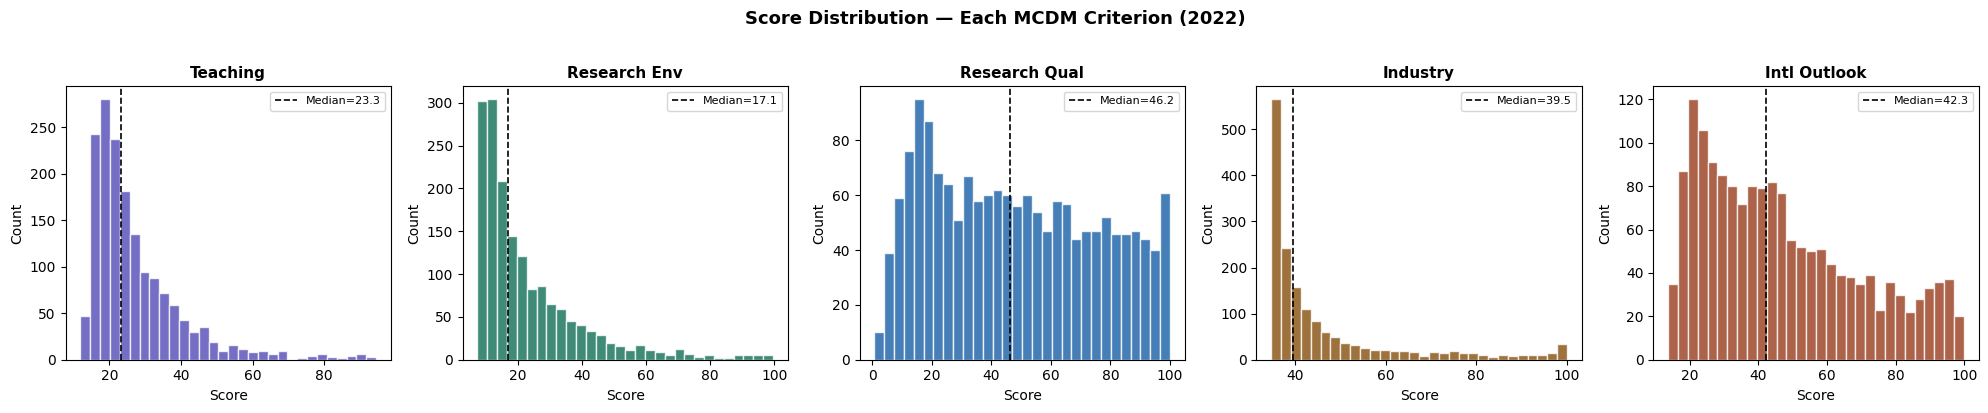

In [14]:
# Score Distribution for each criterion
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
colors = ['#534AB7', '#0F6E56', '#185FA5', '#854F0B', '#993C1D']

for i, col in enumerate(criteria_cols):
    axes[i].hist(df[col].dropna(), bins=30, color=colors[i], alpha=0.8, edgecolor='white')
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Score')
    axes[i].set_ylabel('Count')
    axes[i].axvline(df[col].median(), color='black', linestyle='--', linewidth=1.2, label=f'Median={df[col].median():.1f}')
    axes[i].legend(fontsize=8)

plt.suptitle('Score Distribution — Each MCDM Criterion (2022)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_distributions_2022.png', bbox_inches='tight', dpi=150)
plt.show()

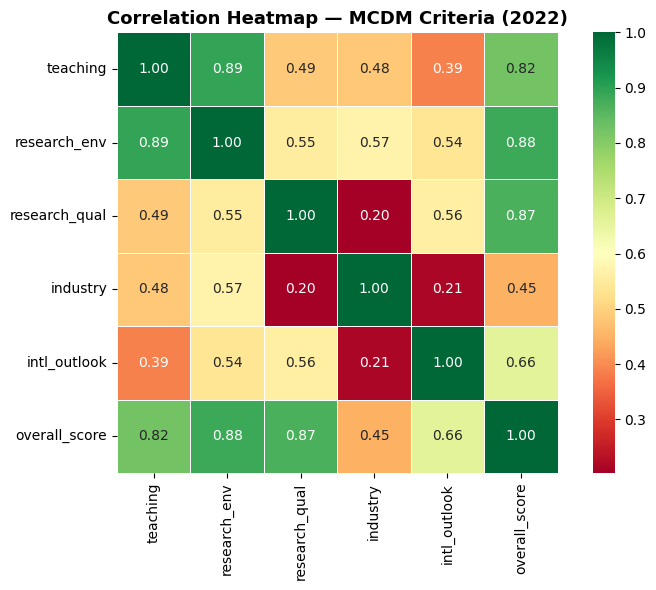

In [15]:
# Correlation Heatmap
corr_cols = criteria_cols + ['overall_score']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='RdYlGn',
    linewidths=0.5,
    square=True,
    annot_kws={'size': 10}
)
plt.title('Correlation Heatmap — MCDM Criteria (2022)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation_2022.png', bbox_inches='tight', dpi=150)
plt.show()

In [16]:
# Top 20 Universities by Overall Score
top20 = df.nlargest(20, 'overall_score')[['university', 'country', 'overall_score', 'rank']]

fig = px.bar(
    top20.sort_values('overall_score'),
    x='overall_score', y='university',
    orientation='h',
    color='overall_score',
    color_continuous_scale='Viridis',
    text='overall_score',
    title='Top 20 Universities by Overall Score (2022)',
    labels={'overall_score': 'Overall Score', 'university': ''}
)
fig.update_traces(texttemplate='%{text:.1f}', textposition='outside')
fig.update_layout(height=600, showlegend=False)
fig.show()

In [17]:
# Country wise University Count (Top 15 countries)
country_counts = df['country'].value_counts().head(15).reset_index()
country_counts.columns = ['country', 'count']

fig = px.bar(
    country_counts,
    x='country', y='count',
    color='count',
    color_continuous_scale='Blues',
    title='Top 15 Countries by Number of Ranked Universities (2022)',
    labels={'count': 'Number of Universities', 'country': 'Country'},
    text='count'
)
fig.update_traces(textposition='outside')
fig.update_layout(xaxis_tickangle=-35)
fig.show()

In [18]:
# Radar Chart — Top 5 Universities across all criteria
top5 = df.nlargest(5, 'overall_score')[['university'] + criteria_cols]

fig = go.Figure()
for _, row in top5.iterrows():
    fig.add_trace(go.Scatterpolar(
        r=row[criteria_cols].tolist() + [row[criteria_cols[0]]],
        theta=[c.replace('_', ' ').title() for c in criteria_cols] + [criteria_cols[0].replace('_', ' ').title()],
        fill='toself',
        name=row['university'][:30]
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 100])),
    title='Radar Chart — Top 5 Universities across All Criteria (2022)',
    height=500
)
fig.show()

In [19]:
# Boxplot — Score spread per criterion
df_melted = df[criteria_cols].melt(var_name='Criterion', value_name='Score')
df_melted['Criterion'] = df_melted['Criterion'].str.replace('_', ' ').str.title()

fig = px.box(
    df_melted,
    x='Criterion', y='Score',
    color='Criterion',
    title='Score Spread per Criterion (2022)',
    points='outliers'
)
fig.update_layout(showlegend=False)
fig.show()

---
## Normalization
We use **Min-Max normalization** so all criteria are on the same 0–1 scale.
All 5 criteria are **benefit** criteria (higher = better).

In [20]:
# Min-Max Normalization
df_norm = df[['university', 'country', 'rank'] + criteria_cols].copy()

for col in criteria_cols:
    col_min = df_norm[col].min()
    col_max = df_norm[col].max()
    df_norm[col + '_norm'] = (df_norm[col] - col_min) / (col_max - col_min)

norm_cols = [c + '_norm' for c in criteria_cols]

print('=== Normalized Scores (first 5 rows) ===')
df_norm[['university'] + norm_cols].head()

=== Normalized Scores (first 5 rows) ===


,university,teaching_norm,research_env_norm,research_qual_norm,industry_norm,intl_outlook_norm
0,University of Oxford,0.9576,1.0000,0.9799,0.6074,0.9582
1,California Institute of Technology,0.9891,0.9707,0.9778,0.8528,0.8130
2,Harvard University,1.0000,0.9924,0.9919,0.2163,0.7666
3,Stanford University,0.9734,0.9696,0.9990,0.8620,0.7654
4,Massachusetts Institute of Technology,0.9564,0.9436,0.9970,0.9034,0.8839


In [21]:
# Verify normalization range
print('Min and Max after normalization (should be 0 and 1):')
print(df_norm[norm_cols].agg(['min', 'max']).round(4))

Min and Max after normalization (should be 0 and 1):
     teaching_norm  research_env_norm  research_qual_norm  industry_norm  \
min         0.0000             0.0000              0.0000         0.0000   
max         1.0000             1.0000              1.0000         1.0000   

     intl_outlook_norm  
min             0.0000  
max             1.0000  


---
## Entropy Weight Calculation
Entropy method objectively assigns weights based on **data variability**.
A criterion with more variation gets a higher weight.

In [22]:
def entropy_weights(norm_matrix):
    """
    Calculate objective weights using Shannon Entropy method.
    norm_matrix: numpy array of normalized values (rows=alternatives, cols=criteria)
    Returns: array of weights summing to 1
    """
    n, m = norm_matrix.shape

    #  Normalize each column to get probability matrix
    col_sums = norm_matrix.sum(axis=0)
    # Avoid division by zero
    col_sums[col_sums == 0] = 1e-10
    p = norm_matrix / col_sums

    # Replace 0s to avoid log(0)
    p = np.where(p == 0, 1e-10, p)

    # Calculate entropy for each criterion
    k = 1 / np.log(n)   # normalization constant
    entropy = -k * np.sum(p * np.log(p), axis=0)

    # Degree of diversification
    diversification = 1 - entropy

    # Normalize to get final weights
    weights = diversification / diversification.sum()
    return weights, entropy


# Apply entropy weights
norm_matrix = df_norm[norm_cols].values
entropy_w, entropy_vals = entropy_weights(norm_matrix)

print('=== Entropy Weights ===')
entropy_df = pd.DataFrame({
    'Criterion'        : criteria_cols,
    'Entropy'          : entropy_vals.round(4),
    'Diversification'  : (1 - entropy_vals).round(4),
    'Entropy_Weight'   : entropy_w.round(4)
})
print(entropy_df.to_string(index=False))
print(f'\nSum of weights: {entropy_w.sum():.4f}')

=== Entropy Weights ===
    Criterion  Entropy  Diversification  Entropy_Weight
     teaching   0.9611           0.0389          0.1486
 research_env   0.9377           0.0623          0.2380
research_qual   0.9753           0.0247          0.0942
     industry   0.8970           0.1030          0.3931
 intl_outlook   0.9669           0.0331          0.1262

Sum of weights: 1.0000


In [23]:
# Visualize Entropy Weights
fig = px.bar(
    entropy_df,
    x='Criterion', y='Entropy_Weight',
    color='Entropy_Weight',
    color_continuous_scale='Purples',
    title='Entropy Weights for Each Criterion (2022)',
    text='Entropy_Weight'
)
fig.update_traces(texttemplate='%{text:.3f}', textposition='outside')
fig.update_layout(showlegend=False)
fig.show()

---
## AHP Weight Calculation
AHP (Analytic Hierarchy Process) uses a **pairwise comparison matrix** based on expert judgment.
Scale: 1=equal, 3=moderate, 5=strong, 7=very strong, 9=extreme importance.

In [24]:
# Pairwise Comparison Matrix
# Criteria order: teaching, research_env, research_qual, industry, intl_outlook
# Judgment: Research Quality > Research Env > Teaching > Intl Outlook > Industry

ahp_matrix = np.array([
    #teach  res_env  res_qual  industry  intl_out
    [1,     1/2,     1/3,      3,        2      ],  # teaching
    [2,     1,       1/2,      4,        3      ],  # research_env
    [3,     2,       1,        5,        4      ],  # research_qual
    [1/3,   1/4,     1/5,      1,        1/2    ],  # industry
    [1/2,   1/3,     1/4,      2,        1      ],  # intl_outlook
])

print('AHP Pairwise Comparison Matrix:')
ahp_df_display = pd.DataFrame(
    ahp_matrix,
    index=criteria_cols,
    columns=criteria_cols
)
print(ahp_df_display.round(3))

AHP Pairwise Comparison Matrix:
               teaching  research_env  research_qual  industry  intl_outlook
teaching         1.0000        0.5000         0.3330    3.0000        2.0000
research_env     2.0000        1.0000         0.5000    4.0000        3.0000
research_qual    3.0000        2.0000         1.0000    5.0000        4.0000
industry         0.3330        0.2500         0.2000    1.0000        0.5000
intl_outlook     0.5000        0.3330         0.2500    2.0000        1.0000


In [25]:
def ahp_weights(matrix):
    """
    Calculate AHP weights and check consistency.
    Returns: weights array, Consistency Ratio (CR)
    """
    n = matrix.shape[0]

    # Normalize each column
    col_sums = matrix.sum(axis=0)
    norm_matrix = matrix / col_sums

    # Average each row = priority vector (weights)
    weights = norm_matrix.mean(axis=1)

    # Consistency check
    weighted_sum = matrix @ weights
    lambda_max = (weighted_sum / weights).mean()

    CI = (lambda_max - n) / (n - 1)

    # Random Index table (Saaty)
    RI_dict = {1: 0, 2: 0, 3: 0.58, 4: 0.90, 5: 1.12,
               6: 1.24, 7: 1.32, 8: 1.41, 9: 1.45, 10: 1.49}
    RI = RI_dict.get(n, 1.49)
    CR = CI / RI if RI != 0 else 0

    return weights, CR, lambda_max, CI


ahp_w, CR, lambda_max, CI = ahp_weights(ahp_matrix)

print('=== AHP Results ===')
ahp_result_df = pd.DataFrame({'Criterion': criteria_cols, 'AHP_Weight': ahp_w.round(4)})
print(ahp_result_df.to_string(index=False))
print(f'\nlambda_max : {lambda_max:.4f}')
print(f'CI         : {CI:.4f}')
print(f'CR         : {CR:.4f}')
if CR < 0.10:
    print('Consistency check: PASSED (CR < 0.10) — matrix is consistent')
else:
    print('WARNING: CR >= 0.10 — revise pairwise comparison matrix')

=== AHP Results ===
    Criterion  AHP_Weight
     teaching      0.1611
 research_env      0.2618
research_qual      0.4162
     industry      0.0624
 intl_outlook      0.0986

lambda_max : 5.0683
CI         : 0.0171
CR         : 0.0153
Consistency check: PASSED (CR < 0.10) — matrix is consistent


In [26]:
# Combined Final Weights (Entropy + AHP average)
# Equal blending of objective (Entropy) and subjective (AHP) weights
final_weights = 0.5 * entropy_w + 0.5 * ahp_w
final_weights = final_weights / final_weights.sum()  # renormalize

print('=== Final Combined Weights ===')
weight_df = pd.DataFrame({
    'Criterion'     : criteria_cols,
    'Entropy_W'     : entropy_w.round(4),
    'AHP_W'         : ahp_w.round(4),
    'Final_W'       : final_weights.round(4)
})
print(weight_df.to_string(index=False))
print(f'\nSum of final weights: {final_weights.sum():.4f}')

=== Final Combined Weights ===
    Criterion  Entropy_W  AHP_W  Final_W
     teaching     0.1486 0.1611   0.1548
 research_env     0.2380 0.2618   0.2499
research_qual     0.0942 0.4162   0.2552
     industry     0.3931 0.0624   0.2277
 intl_outlook     0.1262 0.0986   0.1124

Sum of final weights: 1.0000


In [27]:
# Visualize Weight Comparison
fig = go.Figure()
fig.add_trace(go.Bar(name='Entropy', x=criteria_cols, y=entropy_w, marker_color='#534AB7'))
fig.add_trace(go.Bar(name='AHP',     x=criteria_cols, y=ahp_w,     marker_color='#0F6E56'))
fig.add_trace(go.Bar(name='Final',   x=criteria_cols, y=final_weights, marker_color='#993C1D'))

fig.update_layout(
    barmode='group',
    title='Weight Comparison: Entropy vs AHP vs Final (2022)',
    xaxis_title='Criterion',
    yaxis_title='Weight'
)
fig.show()

---
## TOPSIS Ranking
TOPSIS finds the university closest to the **ideal best** and farthest from the **ideal worst**.

In [28]:
def topsis(norm_matrix, weights):
    """
    TOPSIS ranking.
    norm_matrix : 2D numpy array (alternatives x criteria) — already normalized 0-1
    weights     : 1D array of weights (sum=1)
    Returns     : closeness scores (higher = better), ideal best, ideal worst
    """
    # Weighted normalized matrix
    weighted = norm_matrix * weights

    # Ideal Best (max of each column) and Ideal Worst (min of each column)
    ideal_best  = weighted.max(axis=0)
    ideal_worst = weighted.min(axis=0)

    # Distance from ideal best and ideal worst (Euclidean)
    d_best  = np.sqrt(((weighted - ideal_best)  ** 2).sum(axis=1))
    d_worst = np.sqrt(((weighted - ideal_worst) ** 2).sum(axis=1))

    # Closeness coefficient (higher = better)
    closeness = d_worst / (d_best + d_worst)

    return closeness, ideal_best, ideal_worst, d_best, d_worst


# TOPSIS
closeness, ideal_best, ideal_worst, d_best, d_worst = topsis(norm_matrix, final_weights)

# Add results to dataframe
df_result = df_norm[['university', 'country', 'rank'] + criteria_cols].copy()
df_result['d_best']     = d_best.round(6)
df_result['d_worst']    = d_worst.round(6)
df_result['closeness']  = closeness.round(6)
df_result['mcdm_rank']  = df_result['closeness'].rank(ascending=False).astype(int)

df_result.sort_values('mcdm_rank', inplace=True)
df_result.reset_index(drop=True, inplace=True)

print('=== TOPSIS Results — Top 20 ===')
df_result[['mcdm_rank', 'university', 'country', 'closeness', 'rank']].head(20)

=== TOPSIS Results — Top 20 ===


,mcdm_rank,university,country,closeness,rank
0,1,Massachusetts Institute of Technology,United States,0.9363,5.0000
1,2,California Institute of Technology,United States,0.9148,2.0000
2,3,Stanford University,United States,0.9127,4.0000
3,4,Princeton University,United States,0.8990,7.0000
4,5,Johns Hopkins University,United States,0.8861,14.0000
5,6,"University of California, Berkeley",United States,0.8686,8.0000
6,7,Peking University,China,0.8517,16.0000
7,8,Tsinghua University,China,0.8509,17.0000
8,9,Duke University,United States,0.8399,23.0000
9,10,University of Oxford,United Kingdom,0.8242,1.0000


In [29]:
# Compare MCDM rank vs Official THE rank
df_result['rank_diff'] = df_result['rank'] - df_result['mcdm_rank']

print('=== Top 20: MCDM Rank vs Official THE Rank ===')
compare_df = df_result[['mcdm_rank', 'rank', 'rank_diff', 'university', 'closeness']].head(20)
compare_df.columns = ['MCDM Rank', 'THE Rank', 'Difference', 'University', 'Closeness']
print(compare_df.to_string(index=False))

=== Top 20: MCDM Rank vs Official THE Rank ===
 MCDM Rank  THE Rank  Difference                                  University  Closeness
         1    5.0000      4.0000       Massachusetts Institute of Technology     0.9363
         2    2.0000      0.0000          California Institute of Technology     0.9148
         3    4.0000      1.0000                         Stanford University     0.9127
         4    7.0000      3.0000                        Princeton University     0.8990
         5   14.0000      9.0000                    Johns Hopkins University     0.8861
         6    8.0000      2.0000          University of California, Berkeley     0.8686
         7   16.0000      9.0000                           Peking University     0.8517
         8   17.0000      9.0000                         Tsinghua University     0.8509
         9   23.0000     14.0000                             Duke University     0.8399
        10    1.0000     -9.0000                        University of Oxf

In [30]:
# Visualize Top 20 MCDM Ranking
top20_result = df_result.head(20).copy()
top20_result['short_name'] = top20_result['university'].str[:35]

fig = px.bar(
    top20_result.sort_values('closeness'),
    x='closeness', y='short_name',
    orientation='h',
    color='closeness',
    color_continuous_scale='Viridis',
    text='mcdm_rank',
    title='Top 20 Universities — MCDM Ranking (TOPSIS, 2022)',
    labels={'closeness': 'Closeness Score', 'short_name': ''}
)
fig.update_traces(texttemplate='Rank %{text}', textposition='outside')
fig.update_layout(height=600, showlegend=False)
fig.show()

In [31]:
# Scatter: MCDM Rank vs THE Official Rank
fig = px.scatter(
    df_result.head(100),
    x='rank', y='mcdm_rank',
    hover_name='university',
    color='rank_diff',
    color_continuous_scale='RdYlGn',
    title='MCDM Rank vs Official THE Rank — Top 100 (2022)',
    labels={'rank': 'Official THE Rank', 'mcdm_rank': 'MCDM Rank'}
)
# Add diagonal reference line (perfect agreement)
fig.add_shape(type='line', x0=1, y0=1, x1=100, y1=100,
              line=dict(color='gray', dash='dash'))
fig.show()

---
## Validation — Spearman Rank Correlation

In [32]:
from scipy.stats import spearmanr, kendalltau

# Use only rows where both ranks are available
valid = df_result.dropna(subset=['rank', 'mcdm_rank'])

spearman_r, spearman_p = spearmanr(valid['rank'], valid['mcdm_rank'])
kendall_t,  kendall_p  = kendalltau(valid['rank'], valid['mcdm_rank'])

print('=== Validation Results (2022) ===')
print(f'Spearman Rank Correlation : r = {spearman_r:.4f}  (p = {spearman_p:.4f})')
print(f'Kendall Tau               : τ = {kendall_t:.4f}  (p = {kendall_p:.4f})')
print()
if abs(spearman_r) >= 0.85:
    print('Result: STRONG agreement between MCDM ranking and official THE ranking')
elif abs(spearman_r) >= 0.70:
    print('Result: MODERATE agreement between MCDM ranking and official THE ranking')
else:
    print('Result: WEAK agreement — review criteria weights')

=== Validation Results (2022) ===
Spearman Rank Correlation : r = 0.9673  (p = 0.0000)
Kendall Tau               : τ = 0.8617  (p = 0.0000)

Result: STRONG agreement between MCDM ranking and official THE ranking


---
## Sensitivity Analysis
Check if rankings are stable when weights are perturbed by ±10% and ±20%.

In [33]:
def perturb_and_rank(norm_matrix, base_weights, criterion_idx, delta):
    """Perturb one criterion weight by delta, redistribute evenly, rerun TOPSIS."""
    new_weights = base_weights.copy()
    new_weights[criterion_idx] += delta
    # Redistribute the change equally among other criteria
    others = [i for i in range(len(new_weights)) if i != criterion_idx]
    new_weights[others] -= delta / len(others)
    new_weights = np.clip(new_weights, 0, 1)
    new_weights /= new_weights.sum()  # renormalize
    closeness_new, _, _, _, _ = topsis(norm_matrix, new_weights)
    ranks_new = pd.Series(closeness_new).rank(ascending=False).astype(int).values
    return ranks_new


base_ranks = df_result['mcdm_rank'].values
sensitivity_results = []

for delta in [-0.20, -0.10, +0.10, +0.20]:
    for i, crit in enumerate(criteria_cols):
        new_ranks = perturb_and_rank(norm_matrix, final_weights.copy(), i, delta)
        # Compare top-10 stability
        top10_base = set(np.where(base_ranks <= 10)[0])
        top10_new  = set(np.where(new_ranks  <= 10)[0])
        overlap = len(top10_base & top10_new)
        sensitivity_results.append({
            'criterion': crit,
            'delta'    : f'{delta:+.0%}',
            'top10_overlap': overlap
        })

sens_df = pd.DataFrame(sensitivity_results)
sens_pivot = sens_df.pivot(index='criterion', columns='delta', values='top10_overlap')
print('=== Sensitivity Analysis — Top-10 Overlap with Base Ranking ===')
print('(10 = perfectly stable, lower = more sensitive)')
print(sens_pivot)

=== Sensitivity Analysis — Top-10 Overlap with Base Ranking ===
(10 = perfectly stable, lower = more sensitive)
delta          +10%  +20%  -10%  -20%
criterion                            
industry          5     3     6     8
intl_outlook      6     6     5     5
research_env      6     6     5     5
research_qual     6     6     6     6
teaching          6     6     5     5


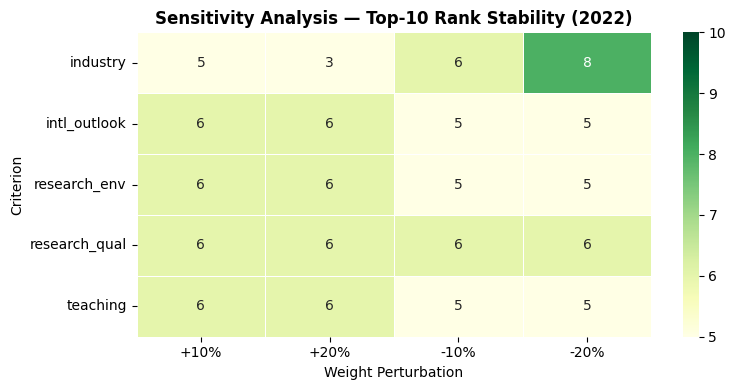

In [34]:
# Heatmap of sensitivity
plt.figure(figsize=(8, 4))
sns.heatmap(sens_pivot, annot=True, fmt='d', cmap='YlGn',
            linewidths=0.5, vmin=5, vmax=10)
plt.title('Sensitivity Analysis — Top-10 Rank Stability (2022)', fontweight='bold')
plt.ylabel('Criterion')
plt.xlabel('Weight Perturbation')
plt.tight_layout()
plt.savefig('sensitivity_2022.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Save Final Results

In [ ]:
# Save full results with MCDM rank
final_output = df_result[[
    'mcdm_rank', 'university', 'country',
    'rank', 'closeness', 'rank_diff',
    'd_best', 'd_worst'
] + criteria_cols].copy()

final_output.insert(0, 'year', 2022)
final_output.to_csv('2022_mcdm_results.csv', index=False)

# Download from Colab
from google.colab import files
files.download('2022_mcdm_results.csv')
files.download('2022_cleaned.csv')

print('Files saved and downloaded!')
print(f'Total universities ranked: {len(final_output)}')
print()
print('=== Summary ===')
print(f'Spearman r       : {spearman_r:.4f}')
print(f'Kendall Tau      : {kendall_t:.4f}')
print(f'Top-1 (MCDM)     : {final_output.iloc[0]["university"]}')
print(f'Top-1 (Official) : {df_result[df_result["rank"]==1]["university"].values[0]}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Files saved and downloaded!
Total universities ranked: 1662

=== Summary ===
Spearman r       : 0.9673
Kendall Tau      : 0.8617
Top-1 (MCDM)     : Massachusetts Institute of Technology
Top-1 (Official) : University of Oxford


In [35]:
# Save weights for Phase 2
import json

weights_data = {
    'year'          : 2022,
    'criteria'      : criteria_cols,
    'entropy_weights': entropy_w.tolist(),
    'ahp_weights'   : ahp_w.tolist(),
    'final_weights' : final_weights.tolist(),
    'data_min'      : df[criteria_cols].min().tolist(),
    'data_max'      : df[criteria_cols].max().tolist()
}

with open('weights_2022.json', 'w') as f:
    json.dump(weights_data, f, indent=4)

files.download('weights_2022.json')
print('Weights saved!')
print(weights_data)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Weights saved!
{'year': 2022, 'criteria': ['teaching', 'research_env', 'research_qual', 'industry', 'intl_outlook'], 'entropy_weights': [0.14855099599087127, 0.23798093337055468, 0.09420055006815821, 0.3930772925934698, 0.12619022797694604], 'ahp_weights': [0.1610504069885031, 0.261787988116735, 0.41621244545530517, 0.06237638655248462, 0.09857277288697212], 'final_weights': [0.15480070148968716, 0.24988446074364484, 0.2552064977617317, 0.2277268395729772, 0.11238150043195907], 'data_min': [11.9, 7.4, 0.7, 34.8, 13.8], 'data_max': [94.5, 99.6, 100.0, 100.0, 99.9]}
